# Teleportation Protocol

This is the second part of the QuTiP tutorial at Euroscipy 2026.
We are going to create some Bell states and finally see how they can be used to teleport a quantum state from Alice to Bob.

In [1]:
import qutip as qt
import numpy as np
from qutip_qip.operations import snot, cnot
from qutip_qip.circuit import QubitCircuit

# Bell States

Bell states are a common tool used in quantum computing.
They involve two qubits, which are maximally entangled.
Two qubits means that our Hilbert space is 4 dimensional, and can be spanned by $|00\rangle, |01\rangle, |10\rangle, |11\rangle$.

The Bell states are equal superpositions of these states:

$$|\Phi^+ \rangle = (|00\rangle + |11\rangle) / \sqrt{2} \qquad
|\Phi^- \rangle = (|00\rangle - |11\rangle) / \sqrt{2} \\
|\Psi^+ \rangle = (|01\rangle + |10\rangle) / \sqrt{2} \qquad
|\Psi^- \rangle = (|01\rangle - |10\rangle) / \sqrt{2}$$

We will create such states by using two qubits and applying a Hadamard gate and a CNOT gate to them.
Depending on the initial state of the qubits, the different Bell states can be created.

In [2]:
def bloch_state(theta, phi):
    """
    Return a single-qubit state |psi> on the Bloch sphere.
    theta, phi in radians.
    """
    zero = qt.basis(2, 0)
    one = qt.basis(2, 1)
    return np.cos(theta/2) * zero + np.exp(1j * phi) * np.sin(theta/2) * one

def plot_on_bloch(states, labels=None):
    """
    Plot one or more states on the Bloch sphere.
    states: list of Qobj kets or a single Qobj.
    labels: optional list of labels.
    """
    if isinstance(states, qt.Qobj):
        states = [states]
    b = qt.Bloch()
    for i, s in enumerate(states):
        b.add_states(s)
        if labels is not None:
            b.add_annotation(s, labels[i])
    b.show()

In [3]:
# Initial state |01>
zero = qt.basis(2, 0)
one = qt.basis(2, 1)
state0 = zero & one

# Apply H on qubit 0
state1 = (snot() & qt.qeye(2)) * state0

# Apply CNOT (control=0, target=1)
state1 = cnot(N=2, control=0, target=1) * state1

# Final state ( |01> + |10> ) / sqrt(2)
state1

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.        ]
 [0.70710678]
 [0.70710678]
 [0.        ]]

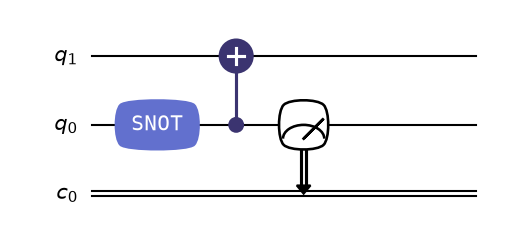

In [4]:
# Initialize Circuit
circ = QubitCircuit(N=2, num_cbits=1)

# Entangled state creation
circ.add_gate("SNOT", targets=[0])
circ.add_gate("CNOT", targets=[1], controls=[0])

# Measure one qubit
circ.add_measurement("M", targets=[0], classical_store=0)
circ.draw("matplotlib")

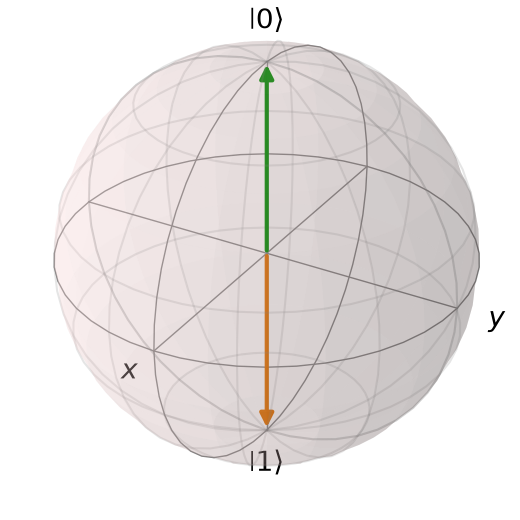

In [5]:
# Run again and again to see different outcomes
statef = circ.run(state0)
plot_on_bloch([statef.ptrace(i) for i in range(2)])

# Teleportation Protocol

Alice and Bob want to teleport a qubit over long distances.
In this tutorial we show how this can be done by using the entanglement between an initially shared Bell state.

In [6]:
def random_single_qubit_state():
    # Sample a random point on the Bloch sphere
    theta = np.arccos(1 - 2*np.random.rand())
    phi = 2 * np.pi * np.random.rand()
    return bloch_state(theta, phi)

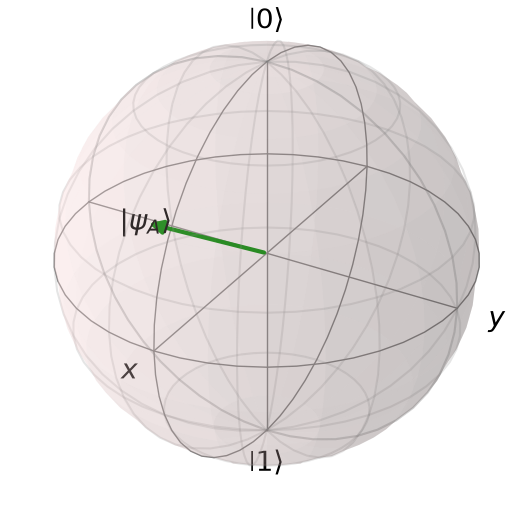

In [7]:
psi = random_single_qubit_state()
plot_on_bloch(psi, labels=[r"$|\psi_A\rangle$"])

In [8]:
# Define 3-qubit initial state
q1 = qt.basis(2, 0)
q2 = qt.basis(2, 0)
state0 = psi & q1 & q2

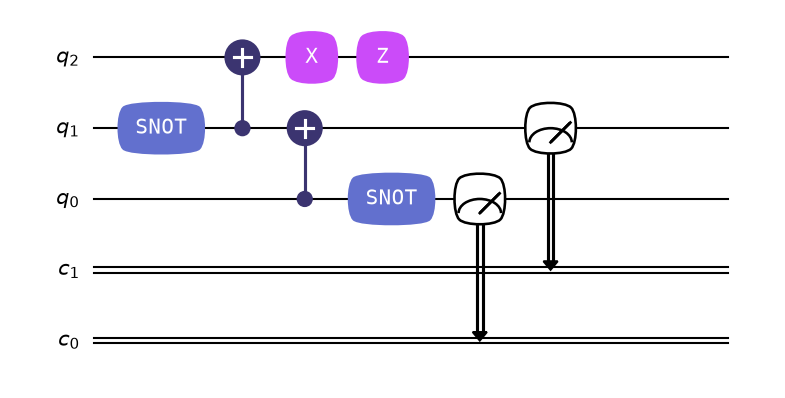

In [9]:
# Initialize Circuit
circ = QubitCircuit(N=3, num_cbits=2)

# Entangled state creation
circ.add_gate("SNOT", targets=[1])
circ.add_gate("CNOT", targets=[2], controls=[1])

# Bell measurement
circ.add_gate("CNOT", targets=[1], controls=[0])
circ.add_gate("SNOT", targets=[0])

# Measure Alice side
circ.add_measurement("M0", targets=[0], classical_store=0)
circ.add_measurement("M1", targets=[1], classical_store=1)

# Measure Bob side
circ.add_gate("X", targets=[2], classical_controls=[1])
circ.add_gate("Z", targets=[2], classical_controls=[0])

circ.draw("matplotlib")

In [10]:
state_final = circ.run(state0)
bob_state = state_final.ptrace(2)
qt.metrics.fidelity(bob_state, psi)

np.float64(1.0000000166600045)

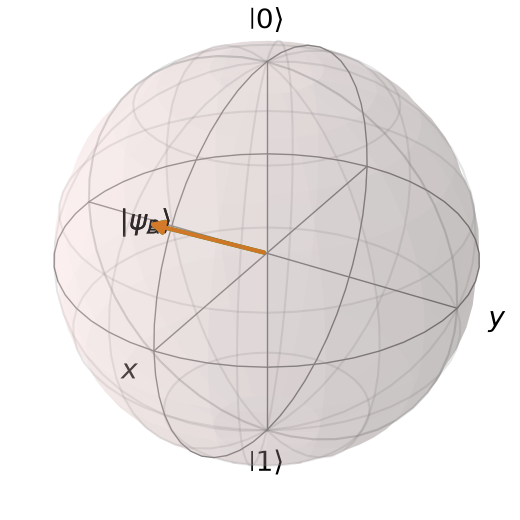

In [11]:
plot_on_bloch([psi, bob_state],
              labels=[r"$|\psi_A\rangle$", r"$|\psi_B\rangle$"])

In [12]:
qt.about()


QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Simon Cross, Asier Galicia, Paul Menczel, and Patrick Hopf.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      5.3.1
Numpy Version:      2.5.3
Scipy Version:      1.18.1
Cython Version:     3.3.0
Matplotlib Version: 3.11.2
Python Version:     3.12.0
Number of CPUs:     4
BLAS Info:          blas
INTEL MKL Ext:      None
Platform Info:      Linux (x86_64)
Installation path:  /home/runner/miniconda3/envs/test-environment-v5/lib/python3.12/site-packages/qutip

Installed QuTiP family packages
-------------------------------



qutip-qoc: 0.3.0.dev0+43e228e
qutip-qtrl: 0.2.1.dev0+83364c3
qutip-qip: 0.4.2
qutip-jax: 0.1.1

Please cite QuTiP in your publication.
For your convenience a bibtex reference can be easily generated using `qutip.cite()`
